# Figure 2S1: Reward-Rate Summary

## What this notebook does

Summarises performance across OL and MX data sets as reward rate (RR) expressed as a
percentage of the ideal-observer RR (computed from simulation). Two panels stacked
vertically, one per data set:

- **Panel 1 — OL (Blocked SNR)**: all 6 raw blocks. Blocks 1–3 = low SNR
  (generative_mean 0.05, SNR ≈ 0.33); blocks 4–6 = high SNR (generative_mean 0.15,
  SNR ≈ 1.0). Ideal RR from 1-D bound sweep.

- **Panel 2 — MX (Mixed SNR)**: all 6 raw blocks. Blocks 1–3 = low+high SNR
  randomly interleaved (generative_means [0.05, 0.15]); blocks 4–6 = medium SNR only
  (generative_mean 0.10, SNR ≈ 0.67). Ideal RR from 1-D bound sweep (single bound
  for both SNR levels, appropriate since subjects cannot know which SNR applies
  trial-by-trial in blocks 1–3).

**Data**: OL and MX loaded with `combine_snr=False` (6 raw blocks each).

## Imports

In [8]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from pigeon.data import get_data_table
from pigeon.simulate import get_simulated_data_table
from pigeon.pathDefaults import FIGURES_DIR

## Load data

Loads OL and MX with `combine_snr=False` to retain all 6 raw blocks per data set.
For OL: blocks 1–3 have a single low SNR; blocks 4–6 have a single high SNR.
For MX: blocks 1–3 interleave low+high SNR; blocks 4–6 use a single medium SNR.

In [9]:
data_table_ol = get_data_table(task_type='OL', combine_snr=False)
data_table_mx = get_data_table(task_type='MX', combine_snr=False)

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

## Simulation parameters and helper

`compute_ideal_rr_curve` sweeps `bound_mean` over `SIM_BOUNDS` and returns median
total-coins/600 per bound value. The maximum of the curve is used as the ideal RR
for that block.

In [10]:
SIM_BOUNDS    = np.arange(0.01, 0.76, 0.01)   # 75 bound values
NUM_SIM_SUBJ  = 100

# Separate seeds so OL and MX results are independent of each other's run order.
rng_ol = np.random.default_rng(0)
rng_mx = np.random.default_rng(1)

# OL: blocks 1-3 = low SNR (g_mean=0.05), blocks 4-6 = high SNR (g_mean=0.15)
OL_BLOCKS = [1, 2, 3, 4, 5, 6]
OL_GMEANS = [0.05, 0.05, 0.05, 0.15, 0.15, 0.15]

# MX: blocks 1-3 = mixed low+high SNR (single bound sweeps with interleaved trials),
#     blocks 4-6 = single medium SNR (g_mean=0.10)
MX_BLOCKS = [1, 2, 3, 4, 5, 6]
MX_GMEANS = [[0.05, 0.15], [0.05, 0.15], [0.05, 0.15], 0.10, 0.10, 0.10]


def compute_ideal_rr_curve(block, generative_mean, sim_bounds, num_sim_subj, rng):
    """Sweep bound_mean over sim_bounds; return array of median total_coins/600.

    Maximum of the curve is the ideal reward rate for this block configuration.
    """
    rr_curve = np.full(len(sim_bounds), np.nan)
    for i, bnd in enumerate(sim_bounds):
        if i % 15 == 0:
            print(f'  bound {i + 1}/{len(sim_bounds)}', end='\r')
        sim = get_simulated_data_table(
            specs={'num_subjects': num_sim_subj, 'blocks': block},
            generative_mean=generative_mean,
            bound_mean=float(bnd),
            correct_bias=None,
            rng=rng,
        )
        coins = sim.groupby('subject_index')['coin_count'].last().to_numpy()
        rr_curve[i] = float(np.nanmedian(coins)) / 600
    print()
    return rr_curve

## Simulate ideal RR — OL blocks 1–6

Blocks 1–3 use low SNR (g_mean=0.05); blocks 4–6 use high SNR (g_mean=0.15).
Each block uses the corresponding `BLOCK_DEFAULTS` reward structure.

In [11]:
ol_ideal_rr  = np.full(6, np.nan)
ol_rr_curves = []

for bi, (block, gm) in enumerate(zip(OL_BLOCKS, OL_GMEANS)):
    print(f'OL block {block} (g_mean={gm})...')
    curve = compute_ideal_rr_curve(block, gm, SIM_BOUNDS, NUM_SIM_SUBJ, rng_ol)
    ol_rr_curves.append(curve)
    ol_ideal_rr[bi] = float(np.nanmax(curve))
    print(f'  ideal RR = {ol_ideal_rr[bi]:.4f}')

print('\nOL ideal RR by block:', np.round(ol_ideal_rr, 4))

OL block 1 (g_mean=0.05)...
  bound 61/75
  ideal RR = 0.2083
OL block 2 (g_mean=0.05)...
  bound 61/75
  ideal RR = 0.0583
OL block 3 (g_mean=0.05)...
  bound 61/75
  ideal RR = 0.0725
OL block 4 (g_mean=0.15)...
  bound 61/75
  ideal RR = 0.2800
OL block 5 (g_mean=0.15)...
  bound 61/75
  ideal RR = 0.2183
OL block 6 (g_mean=0.15)...
  bound 61/75
  ideal RR = 0.2100

OL ideal RR by block: [0.2083 0.0583 0.0725 0.28   0.2183 0.21  ]


## Simulate ideal RR — MX blocks 1–6

Blocks 1–3: `generative_mean=[0.05, 0.15]` → trials from both SNR levels are randomly
interleaved; a single `bound_mean` applies to all trials (appropriate benchmark since
subjects cannot identify which SNR applies on each trial).
Blocks 4–6: single medium SNR (g_mean=0.10).

In [12]:
mx_ideal_rr  = np.full(6, np.nan)
mx_rr_curves = []

for bi, (block, gm) in enumerate(zip(MX_BLOCKS, MX_GMEANS)):
    print(f'MX block {block} (g_mean={gm})...')
    curve = compute_ideal_rr_curve(block, gm, SIM_BOUNDS, NUM_SIM_SUBJ, rng_mx)
    mx_rr_curves.append(curve)
    mx_ideal_rr[bi] = float(np.nanmax(curve))
    print(f'  ideal RR = {mx_ideal_rr[bi]:.4f}')

print('\nMX ideal RR by block:', np.round(mx_ideal_rr, 4))

MX block 1 (g_mean=[0.05, 0.15])...
  bound 61/75
  ideal RR = 0.2450
MX block 2 (g_mean=[0.05, 0.15])...
  bound 61/75
  ideal RR = 0.1008
MX block 3 (g_mean=[0.05, 0.15])...
  bound 61/75
  ideal RR = 0.1100
MX block 4 (g_mean=0.1)...
  bound 61/75
  ideal RR = 0.2500
MX block 5 (g_mean=0.1)...
  bound 61/75
  ideal RR = 0.1483
MX block 6 (g_mean=0.1)...
  bound 61/75
  ideal RR = 0.1433

MX ideal RR by block: [0.245  0.1008 0.11   0.25   0.1483 0.1433]


## Actual RR and OL/MX performance

For each (subject, block), `actual_RR = last_coin_count / 600`.
Performance = actual_RR / ideal_RR × 100 %.

In [13]:
def get_rr_array(data_table, blocks):
    """Return (subjects, rr) where rr has shape (n_subjects, n_blocks)."""
    subjects = np.sort(data_table['subject_index'].dropna().unique())
    dt = data_table.sort_values('trial_number')
    rr = np.full((len(subjects), len(blocks)), np.nan)
    for si, subj in enumerate(subjects):
        for bi, block in enumerate(blocks):
            ls = (dt['subject_index'] == subj) & (dt['block_index'] == block)
            coins = dt.loc[ls, 'coin_count'].dropna()
            if len(coins):
                rr[si, bi] = float(coins.iloc[-1]) / 600
    return subjects, rr


subjects_ol, ol_actual_rr = get_rr_array(data_table_ol, OL_BLOCKS)
subjects_mx, mx_actual_rr = get_rr_array(data_table_mx, MX_BLOCKS)

ol_perf = ol_actual_rr / ol_ideal_rr[None, :] * 100   # (n_ol, 6)
mx_perf = mx_actual_rr / mx_ideal_rr[None, :] * 100   # (n_mx, 6)

print(f'OL: {len(subjects_ol)} subjects')
print(f'  median % ideal by block: {np.round(np.nanmedian(ol_perf, axis=0), 1)}')
print(f'MX: {len(subjects_mx)} subjects')
print(f'  median % ideal by block: {np.round(np.nanmedian(mx_perf, axis=0), 1)}')

OL: 60 subjects
  median % ideal by block: [ 65.2 -12.9  73.6  79.5  65.3  64.7]
MX: 60 subjects
  median % ideal by block: [67.7 43.8 75.8 77.7 63.5 72.1]


## Figure

Publication-quality version. Saves to `Figure02_S01.pdf`.

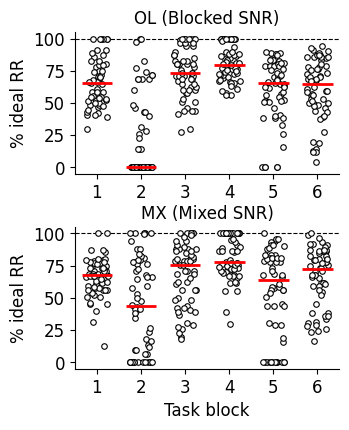

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure02S1_RRSummary_formatted.pdf


In [ ]:
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 8.5
HTS = [4.0, 4.0]
PSH = 1.5
FS  = 12

Y_PAD = 5   # axis padding beyond [0, 100] so clipped points show in full

MARKER_KW = dict(
    marker='o', markerfacecolor='white', markeredgecolor='k',
    markeredgewidth=0.8, markersize=4, linestyle='none',
)

rng_jitter = np.random.default_rng(99)

fig_h   = sum(HTS) + PSH * (len(HTS) - 1)
hspace  = PSH / np.mean(HTS)

fig = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(
    2, 1, figure=fig,
    hspace=hspace,
    left=0.18, right=0.97, bottom=0.07, top=0.97,
)
axs = [fig.add_subplot(gs[r]) for r in range(2)]

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})


def plot_rr_panel(ax, perf, n_blocks, block_labels=None, title=''):
    for bi in range(n_blocks):
        col   = perf[:, bi]
        valid = np.isfinite(col)
        if not valid.any():
            continue
        clipped = np.clip(col[valid], 0, 100)
        jx = (bi + 1) + rng_jitter.uniform(-0.25, 0.25, size=valid.sum())
        ax.plot(jx, clipped, **MARKER_KW)
        med = float(np.nanmedian(clipped))
        ax.plot([bi + 0.65, bi + 1.35], [med, med],
                '-', color='red', linewidth=2, zorder=5, solid_capstyle='butt')
    ax.axhline(100, color='k', linestyle='--', linewidth=0.8, zorder=0)
    ax.set_xlim(0.5, n_blocks + 0.5)
    ax.set_ylim(-Y_PAD, 100 + Y_PAD)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticks(range(1, n_blocks + 1))
    if block_labels is not None:
        ax.set_xticklabels(block_labels, fontsize=FS - 2)
    ax.set_ylabel('% ideal RR')
    ax.set_title(title)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


plot_rr_panel(axs[0], ol_perf, 6, title='OL (Blocked SNR)')
plot_rr_panel(axs[1], mx_perf, 6, title='MX (Mixed SNR)')
axs[1].set_xlabel('Task block')

out = FIGURES_DIR / 'Figure02_S01.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')